# GNSS Multipath Analysis: EDA & ML Data Preparation

This notebook conducts the Exploratory Data Analysis (EDA) and prepares the data for machine learning classification.

**File Architecture:**
- **Input:** `data/02_interim/time_synced_epochs.csv`
- **Output:** `data/03_processed/training_features_labels.csv`


## Step 1: Library Import & Data Loading
Import all necessary libraries for visualization, scaling, SMOTE, and PCA. Load the interim CSV file.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import os

# Load the dataset
file_path = '../../GNSS_Multipath_Project/data/02_interim/time_synced_epochs.csv'
df = pd.read_csv(file_path)

# Display the first few rows
pd.set_option('display.max_columns', None)
print(f"Data loaded successfully from {file_path}")
df.head()

Data loaded successfully from ../../GNSS_Multipath_Project/data/02_interim/time_synced_epochs.csv


,TimeNanos,FullBiasNanos,State,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,MultipathIndicator,AccumulatedDeltaRangeState,GpsTimeNanos,lat_chipset,lon_chipset,lat_span,lon_span,Position_Error_Meters,is_multipath
0,21092250000000,-1273508372192433389,23567,8,36.6,0,25,425464442433280,37.423584,-122.094122,37.423576,-122.094132,1.291996,0
1,21092250000000,-1273508372192433389,23567,14,30.8,0,25,425464442433280,37.423584,-122.094122,37.423576,-122.094132,1.291996,0
2,21092250000000,-1273508372192433389,23567,6,38.7,0,25,425464442433280,37.423584,-122.094122,37.423576,-122.094132,1.291996,0
3,21092250000000,-1273508372192433389,23567,21,26.7,0,27,425464442433280,37.423584,-122.094122,37.423576,-122.094132,1.291996,0
4,21092250000000,-1273508372192433389,23567,8,36.0,0,25,425464442433280,37.423584,-122.094122,37.423576,-122.094132,1.291996,0


## Step 2: Statistical Profiling
Run a `.describe()` and `.info()` on the dataset to audit the continuous signal measurements and categorical hardware flags.

In [3]:
print("--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57405 entries, 0 to 57404
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TimeNanos                       57405 non-null  int64  
 1   FullBiasNanos                   57405 non-null  int64  
 2   State                           57405 non-null  int64  
 3   ReceivedSvTimeUncertaintyNanos  57405 non-null  int64  
 4   Cn0DbHz                         57405 non-null  float64
 5   MultipathIndicator              57405 non-null  int64  
 6   AccumulatedDeltaRangeState      57405 non-null  int64  
 7   GpsTimeNanos                    57405 non-null  int64  
 8   lat_chipset                     57405 non-null  float64
 9   lon_chipset                     57405 non-null  float64
 10  lat_span                        57405 non-null  float64
 11  lon_span                        57405 non-null  float64
 12  Position_Er

,TimeNanos,FullBiasNanos,State,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,MultipathIndicator,AccumulatedDeltaRangeState,GpsTimeNanos,lat_chipset,lon_chipset,lat_span,lon_span,Position_Error_Meters,is_multipath
count,5.740500e+04,5.740500e+04,57405.000000,57405.000000,57405.000000,57405.0,57405.000000,5.740500e+04,57405.000000,57405.000000,57405.000000,57405.000000,57405.000000,57405.000000
mean,2.196507e+13,-1.273508e+18,45034.306890,12.605191,31.489252,0.0,23.743838,4.263373e+14,37.523354,-122.248658,37.523403,-122.248731,9.187406,0.553053
std,4.945085e+11,2.357847e+05,26071.436819,13.104490,6.088295,0.0,3.473157,4.945085e+11,0.069747,0.105686,0.069754,0.105683,3.027786,0.497182
min,2.109225e+13,-1.273508e+18,16399.000000,2.000000,7.300000,0.0,16.000000,4.254644e+14,37.422278,-122.406104,37.422289,-122.406103,0.129346,0.000000
25%,2.154025e+13,-1.273508e+18,23567.000000,5.000000,27.500000,0.0,25.000000,4.259124e+14,37.463658,-122.338415,37.463693,-122.338529,8.798750,0.000000
50%,2.197025e+13,-1.273508e+18,49359.000000,9.000000,31.700000,0.0,25.000000,4.263424e+14,37.513734,-122.255758,37.513801,-122.255834,10.177132,1.000000
75%,2.238525e+13,-1.273508e+18,81935.000000,14.000000,36.000000,0.0,25.000000,4.267574e+14,37.586950,-122.146073,37.586942,-122.146143,10.941252,1.000000
max,2.283025e+13,-1.273508e+18,81935.000000,181.000000,45.300000,0.0,29.000000,4.272024e+14,37.646603,-122.090286,37.646597,-122.090294,12.938698,1.000000


## Step 3: Target Variable Distribution (The Imbalance Check)
Generate a Seaborn countplot for `is_multipath`. Calculate and print the exact percentage of class imbalance (Multipath vs. Clean signals).

Class Imbalance:
is_multipath
1    55.305287
0    44.694713
Name: proportion, dtype: float64



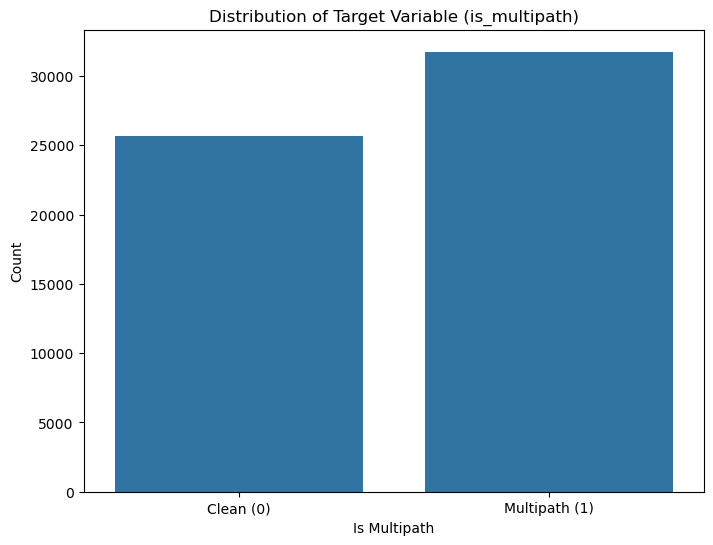

In [4]:
# Calculate class distribution
imbalance = df['is_multipath'].value_counts(normalize=True) * 100
print(f"Class Imbalance:\n{imbalance}\n")

# Visualize the distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='is_multipath', data=df)
plt.title('Distribution of Target Variable (is_multipath)')
plt.xlabel('Is Multipath')
plt.ylabel('Count')
plt.xticks([0, 1], ['Clean (0)', 'Multipath (1)'])
plt.show()

## Step 4: Correlation Analysis
Generate a Seaborn heatmap using a correlation matrix to identify linear relationships between the signal features (like `Cn0DbHz`) and the actual distance error (`Position_Error_Meters`).

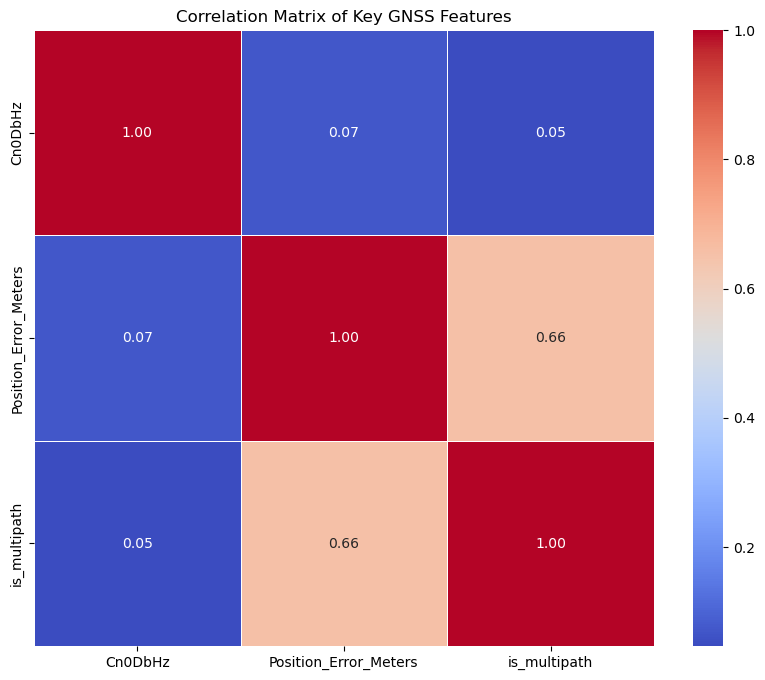

In [12]:
# Select relevant continuous features for correlation analysis
correlation_features = [
    'Cn0DbHz', 'Position_Error_Meters', 'is_multipath'
]
corr_matrix = df[correlation_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Key GNSS Features')
plt.show()

## Step 5: Deep Dive into Key Risk Factors
Create two critical visualizations:
1. A scatter plot of `Cn0DbHz` (x-axis) vs. `Position_Error_Meters` (y-axis) with an alpha of 0.3. Set the y-axis limit to 100 to clearly show the "elbow" where error explodes as signal drops.
2. A boxplot of `MultipathIndicator` (x-axis) vs. `Position_Error_Meters` (y-axis).

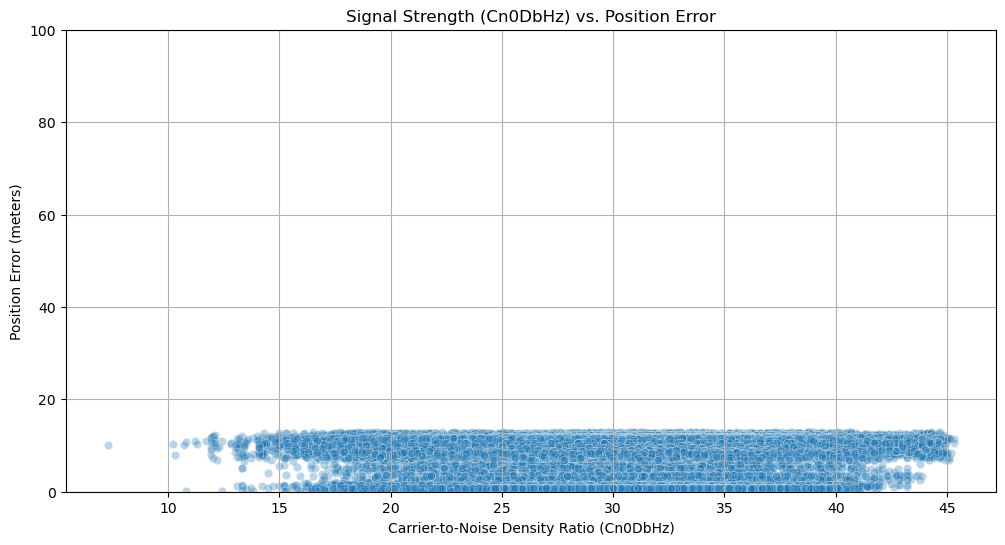

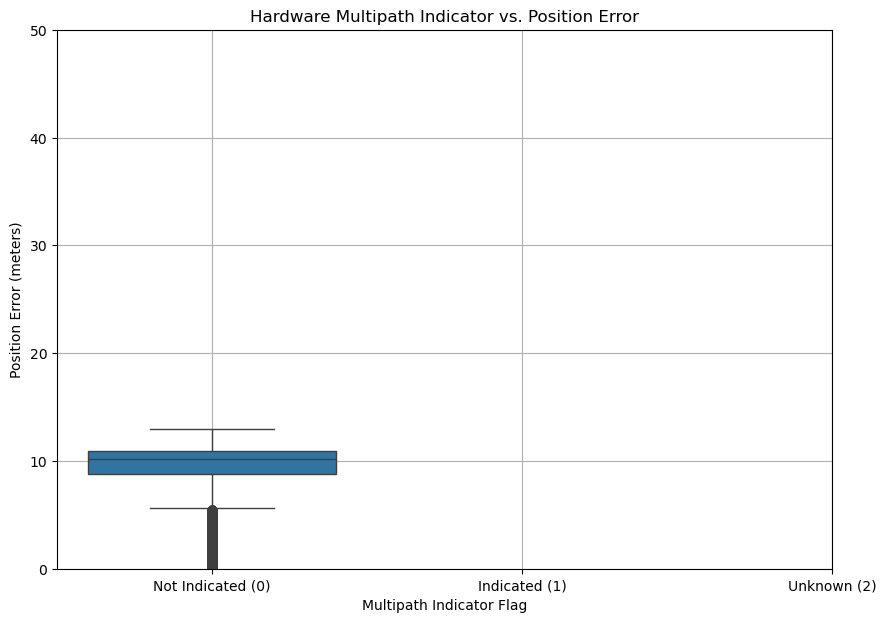

In [ ]:
# Scatter plot of Cn0DbHz vs. Position_Error_Meters
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Cn0DbHz', y='Position_Error_Meters', data=df, alpha=0.3)
plt.title('Signal Strength (Cn0DbHz) vs. Position Error')
plt.xlabel('Carrier-to-Noise Density Ratio (Cn0DbHz)')
plt.ylabel('Position Error (meters)')
plt.ylim(0, 100)  # Set y-axis limit to focus on the critical error range
plt.grid(True)
plt.show()

## Step 6: Signal & Context Matrix (Multivariate Analysis)
Create a Seaborn `pairplot` using a subset of the continuous GNSS features, colored by `hue='is_multipath'` to observe multidimensional separation.

In [ ]:
# Select a subset of features for the pairplot
pairplot_features = [
    'Cn0DbHz', 'Position_Error_Meters', 'is_multipath'
]

# Create the pairplot, using a sample to speed up rendering
print("Generating pairplot... (This may take a moment)")
# Ensure there are enough samples if the dataframe is smaller than 5000
sample_size = min(5000, len(df))
sns.pairplot(df[pairplot_features].sample(n=sample_size, random_state=42), hue='is_multipath', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Continuous Features by Multipath Class', y=1.02)
plt.show()

Generating pairplot... (This may take a moment)


KeyError: "['PseudorangeRateMetersPerSecond', 'CarrierFrequencyHz'] not in index"

## Step 7: Data Quality Summary
Perform a final programmatic check for NaNs or infinite values and drop/impute them if any slipped through the time-synchronization phase.

In [ ]:
# Check for NaN values
nan_counts = df.isnull().sum()
print(f"NaN values per column:\n{nan_counts[nan_counts > 0]}\n")

# Check for infinite values
inf_counts = df.apply(lambda x: np.isinf(x).sum())
print(f"Infinite values per column:\n{inf_counts[inf_counts > 0]}\n")

# Drop rows with NaN or infinite values if any
initial_rows = len(df)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
final_rows = len(df)

print(f"Dropped {initial_rows - final_rows} rows due to NaN or infinite values.")
print(f"Dataset shape after cleaning: {df.shape}")

## Step 8: Feature Selection for Classification
Drop columns that are useful for analysis but should not be fed into the final ML model (e.g., `TimeNanos`, `GpsTime`, raw coordinates, and `Position_Error_Meters` since we are predicting `is_multipath`). Keep only the predictive features and the target label.

In [ ]:
# Define columns to drop
cols_to_drop = [
    'TimeNanos', 'GpsTime', 'UnixTimeMillis', 'utcTimeMillis',
    'LatitudeDegrees', 'LongitudeDegrees', 'AltitudeMeters',
    'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters',
    'UncalibratedLatitudeDegrees', 'UncalibratedLongitudeDegrees', 'UncalibratedAltitudeMeters',
    'Position_Error_Meters', 'Phone' # Drop Phone as it's an identifier
]

# Create the feature set for the ML model
df_ml = df.drop(columns=cols_to_drop, errors='ignore')

print("Columns dropped. Remaining features for ML model:")
print(df_ml.columns)
df_ml.head()

## Step 9: Feature Engineering (Discretization)
Create a new categorical column that bins `Cn0DbHz` into 'Weak' (<25), 'Medium' (25-35), and 'Strong' (>35) signal categories to evaluate non-linear rule mining potential.

In [ ]:
# Define bins and labels for Cn0DbHz
bins = [0, 25, 35, np.inf]
labels = ['Weak', 'Medium', 'Strong']

# Create the new categorical feature
df_ml['Cn0DbHz_Category'] = pd.cut(df_ml['Cn0DbHz'], bins=bins, labels=labels, right=False)

print("Value counts for the new 'Cn0DbHz_Category' feature:")
print(df_ml['Cn0DbHz_Category'].value_counts())
df_ml.head()

## Step 10: Feature Scaling
Apply `StandardScaler` to the continuous GNSS features to prepare them for distance-based algorithms or PCA.

In [ ]:
# Identify continuous features to scale (excluding target and categorical)
continuous_features = df_ml.select_dtypes(include=np.number).columns.drop('is_multipath')

# Initialize the scaler
scaler = StandardScaler()

# Apply the scaler
df_ml[continuous_features] = scaler.fit_transform(df_ml[continuous_features])

print("Continuous features scaled successfully.")
df_ml.describe()

## Step 11: Handling Class Imbalance (Resampling)
Implement `SMOTE` (Synthetic Minority Over-sampling Technique) to balance the feature set if the `is_multipath` class is severely underrepresented. Print the new class distribution.

In [ ]:
# Separate features (X) and target (y)
# Note: We need to handle categorical features before applying SMOTE
X = df_ml.drop('is_multipath', axis=1)
y = df_ml['is_multipath']

# Temporarily handle categorical columns for SMOTE by one-hot encoding them first
X_smote = pd.get_dummies(X, drop_first=True)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE
print("Applying SMOTE to balance the dataset...")
X_resampled, y_resampled = smote.fit_resample(X_smote, y)

print("SMOTE applied successfully.")
print(f"Original dataset shape: {y.shape[0]}")
print(f"Resampled dataset shape: {y_resampled.shape[0]}")
print("\nNew class distribution after SMOTE:")
print(y_resampled.value_counts())

## Step 12: Creation of Transaction Matrix
Apply `pd.get_dummies()` to dummy-encode categorical variables (like the `Cn0DbHz` bins and `MultipathIndicator`). This was partially done for SMOTE, now we formalize it for the final dataset.

In [ ]:
# The X_resampled from the SMOTE step is already our transaction matrix
# We will combine it back with the resampled target variable to have a complete final dataframe
df_final = pd.concat([pd.DataFrame(X_resampled, columns=X_smote.columns), pd.Series(y_resampled, name='is_multipath')], axis=1)

print("Dummy-encoded transaction matrix created.")
print(f"Final dataset shape: {df_final.shape}")
print("Final columns:")
print(df_final.columns)
df_final.head()

## Step 13: Data Transformation with PCA
Run a Principal Component Analysis (PCA) on the scaled feature set. Plot the explained variance ratio to see if dimensionality reduction effectively captures the GNSS variance.

In [ ]:
# Use the resampled and encoded features for PCA
X_final = df_final.drop('is_multipath', axis=1)

# Initialize PCA
pca = PCA()
X_pca = pca.fit_transform(X_final)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.legend()
plt.show()

# Find the number of components to explain 95% of the variance
n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% of variance: {n_components_95}")

## Step 14: Final Data Cleanup & Export
Save the final, scaled, balanced, and engineered DataFrame (without the PCA transformation, just the raw engineered features) to `data/03_processed/training_features_labels.csv` without the index.

In [ ]:
# Define the output path
output_dir = '../../data/03_processed'
output_file = 'training_features_labels.csv'
output_path = os.path.join(output_dir, output_file)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the final DataFrame to a CSV file
df_final.to_csv(output_path, index=False)

print(f"Final engineered dataset saved successfully to: {output_path}")
print(f"Shape of the saved data: {df_final.shape}")